# Ajuste fino (LoRA) do GPT-2 pequeno em portugues - dominio de Negocios

Este notebook segue o passo a passo pedido pelo professor, do inicio ao fim.

| # | Etapa pedida | Onde esta |
|---|---|---|
| 1 | Modelo base `pierreguillou/gpt2-small-portuguese` | Secao 5 |
| 2 | Base do grupo (`data/negocios.jsonl`, 1.200 pares) | Secao 2 |
| 3 | Instalar `transformers peft accelerate` | Secao 1.2 |
| 4 | Carregar modelo e tokenizador (`pad_token = eos_token`) | Secao 5 |
| 5 | Ligar o LoRA (`r=8`, `alpha=16`, `c_attn`, `dropout=0.05`) | Secao 6 |
| 6 | Formatar os pares com marcadores fixos + `eos_token` | Secao 3 |
| 7 | Treinar acompanhando a perda | Secao 7 |
| 8 | Salvar o adaptador e **recarregar com `PeftModel`** | Secoes 8 e 9 |
| 9 | Conversar (`temperatura`, `penalidade`, `top_p`) | Secao 10 |
| + | **Grafico da perda** | Secao 7.4 |
| + | Os 5 parametros que a aplicacao deve expor | Secao 7.1 |
| + | Avaliacao no conjunto de teste e analise de erros | Secoes 11 e 12 |

**Regras do trabalho respeitadas:** nenhuma API de LLM comercial e chamada em nenhum ponto; a base fica
fora do zip da entrega.

## 1. Ambiente e bibliotecas

### 1.1 Conferencia do ambiente

**O que faz:** mostra a versao do Python, o sistema operacional, a pasta de trabalho e se ha GPU com CUDA.

**Por que:** o treino leva poucos minutos na GPU e dezenas de minutos na CPU. Registrar o ambiente evita
tratar lentidao como se fosse erro, e torna o resultado reproduzivel por outra pessoa.

**O que observar:** se `GPU disponivel` for `False`, o notebook ainda roda, mas convem reduzir `EPOCAS`
na Secao 7.1.

In [1]:
from pathlib import Path
import sys, platform

print("Python:", sys.version.split()[0])
print("Sistema:", platform.system(), platform.release())
print("Pasta de trabalho:", Path.cwd())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("GPU disponivel:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print("VRAM:", f"{vram:.2f} GB")
except ImportError:
    print("PyTorch ainda nao instalado - rode a proxima celula.")

Python: 3.14.3
Sistema: Windows 11
Pasta de trabalho: d:\ESTUDOS\UNIFOR\int-aprendizado-maquina
PyTorch: 2.12.1+cu132
GPU disponivel: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.00 GB


### 1.2 Instalacao das bibliotecas

**O que faz:** instala o que o professor pediu (`transformers`, `peft`, `accelerate`) mais os utilitarios
de dados e grafico (`pandas`, `matplotlib`, `scikit-learn`).

**Por que:** `transformers` traz o GPT-2 e o tokenizador; `peft` traz o LoRA; `accelerate` cuida da execucao
em CPU/GPU. `scikit-learn` faz a divisao dos dados e `matplotlib` desenha o grafico da perda.

**Correcao aplicada:** a versao anterior deste projeto **nunca instalava `transformers`**, dependendo de ele
ja existir no ambiente - o notebook quebraria numa maquina limpa ou no Colab. Agora esta explicito.

> `%pip` instala no mesmo interpretador do kernel, ao contrario de `!pip`, que pode acertar outro Python.

In [2]:
%pip install -q transformers peft accelerate pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1.3 Importacoes e sementes de aleatoriedade

**O que faz:** importa as bibliotecas e fixa a semente (`SEMENTE = 42`) do Python, do NumPy e do PyTorch.

**Por que:** varias etapas sorteiam valores - a divisao dos dados, o embaralhamento dos lotes, o `dropout`
do LoRA e a amostragem na geracao. Fixar a semente torna o experimento **reproduzivel**: rodar de novo
entrega os mesmos numeros, o que e essencial para comparar epocas e defender os resultados.

**Limite honesto:** a reprodutibilidade nao e perfeita em GPU, porque alguns kernels CUDA nao sao
deterministicos. Os valores podem variar nas ultimas casas decimais.

In [3]:
import json, time, gc, random, re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEMENTE)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_colwidth", None)

print("Semente fixada em:", SEMENTE)
print("Dispositivo:", dispositivo)

Semente fixada em: 42
Dispositivo: cuda


d:\ESTUDOS\UNIFOR\int-aprendizado-maquina\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. A base do grupo

### 2.1 Carregamento de `data/negocios.jsonl`

**O que faz:** localiza o arquivo, le o formato JSONL (um exemplo por linha) e confere a estrutura pedida
pelo professor: 1.200 pares com os campos `instruction`, `input` e `output`.

**Por que:** o professor manda conferir o formato da base antes de treinar. Os `assert` interrompem cedo se
o arquivo errado for apontado, em vez de produzir um treino silenciosamente invalido.

**O que observar:** devem aparecer 1.200 linhas e 3 colunas. Se o caminho falhar, a celula lista os `.jsonl`
proximos para ajudar a corrigir.

In [4]:
CAMINHO_DADOS = Path("data/negocios.jsonl")

if not CAMINHO_DADOS.exists():
    print("Arquivo NAO encontrado em:", CAMINHO_DADOS.resolve())
    print("Arquivos .jsonl por perto:")
    for achado in Path(".").rglob("*.jsonl"):
        print("  -", achado)
    raise FileNotFoundError(CAMINHO_DADOS)

df = pd.read_json(CAMINHO_DADOS, lines=True)

print("Arquivo:", CAMINHO_DADOS.resolve())
print("Dimensoes (linhas, colunas):", df.shape)
print("Colunas:", df.columns.tolist())

assert list(df.columns) == ["instruction", "input", "output"], "Campos fora do padrao pedido"
assert len(df) == 1200, f"Esperado 1.200 pares, encontrado {len(df)}"

display(df.head(3))

Arquivo: D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\data\negocios.jsonl
Dimensoes (linhas, colunas): (1200, 3)
Colunas: ['instruction', 'input', 'output']


,instruction,input,output
0,Componha um tweet sobre o investimento em criptomoedas.,,Investir em criptomoedas pode ser uma ótima maneira de diversificar seu portfólio e obter um maior retorno sobre seu investimento. #crypto #investing #finance
1,Explique como as listas de tarefas podem ajudar a aumentar a produtividade.,,"As listas de tarefas podem ajudar a aumentar a produtividade, fornecendo uma maneira prática de organizar e priorizar tarefas. Ao dividir as metas em uma lista de etapas acionáveis, é mais fácil permanecer no caminho certo e progredir. As listas de tarefas também podem fornecer motivação e um senso de realização quando as tarefas são concluídas."
2,Explique a diferença entre atendimento ao cliente antecipado e reativo.,,"O atendimento antecipado ao cliente é focado em antecipar as necessidades dos clientes e abordá-las antes que elas surjam. Envolve obter insights sobre as preferências do cliente, desenvolver processos e modelos de negócios que antecipam as necessidades do cliente e aproveitar a tecnologia para melhorar a experiência do cliente. O atendimento ao cliente reativo se concentra em responder de forma rápida e eficaz às solicitações do cliente. Esse tipo de atendimento ao cliente exige que uma empresa tenha um sistema eficiente para monitorar as interações do cliente, determinar as necessidades do cliente e fornecer respostas oportunas."


### 2.2 Qualidade dos dados

**O que faz:** conta valores nulos, textos vazios e duplicatas, e mede a fatia de exemplos com contexto.

**Por que:** o professor avisa que a base tem defeitos deixados de proposito e que o grupo deve **mostrar**
isso, nao esconder. Esta celula e a evidencia numerica dessa parte da apresentacao. Duplicatas importam
porque um exemplo repetido ganha peso extra e incentiva memorizacao.

**Analise esperada:** `instruction` e `output` sem nulos; cerca de **949 `input` vazios (79,1%)**. Ou seja,
1 em cada 5 exemplos traz contexto - fatia pequena demais para ignorar, como a Secao 2.3 demonstra.

In [5]:
colunas_texto = ["instruction", "input", "output"]

resumo = pd.DataFrame({
    "nulos": df[colunas_texto].isna().sum(),
    "vazios": df[colunas_texto].apply(lambda c: c.fillna("").str.strip().eq("").sum()),
})
resumo["pct_vazios"] = (resumo["vazios"] / len(df) * 100).round(2)
display(resumo)

print("Linhas totalmente duplicadas:", df.duplicated().sum())
print("Instrucoes duplicadas:", df.duplicated(subset=["instruction"]).sum())

tem_contexto = df["input"].fillna("").str.strip() != ""
print(f"\nExemplos COM contexto: {tem_contexto.sum()} ({tem_contexto.mean()*100:.1f}%)")
print(f"Exemplos SEM contexto: {(~tem_contexto).sum()} ({(~tem_contexto).mean()*100:.1f}%)")

,nulos,vazios,pct_vazios
instruction,0,0,0.00
input,0,949,79.08
output,0,0,0.00


Linhas totalmente duplicadas: 0
Instrucoes duplicadas: 0

Exemplos COM contexto: 251 (20.9%)
Exemplos SEM contexto: 949 (79.1%)


### 2.3 Por que o campo `input` nao pode ser descartado

**O que faz:** mostra exemplos reais em que a `instruction` sozinha e insuficiente para chegar ao `output`.

**Por que:** esta e a evidencia que fundamenta uma decisao de projeto tomada na Secao 3. O professor descreve
`input` como "contexto opcional, quase sempre vazio", e o formato do passo a passo usa apenas `instruction`.
Nesta base, porem, existem casos como *"Comentario sobre a experiencia recente do cliente no restaurante."* -
sem o `input`, a resposta correta e impossivel de determinar.

**Consequencia:** descartar o `input` transformaria ~21% do treino em exemplos sem solucao, ensinando o modelo
justamente a **inventar**. Por isso o contexto e preservado, mantendo os marcadores do professor intactos.

In [6]:
exemplos_com_contexto = df[tem_contexto].head(2)

for _, linha in exemplos_com_contexto.iterrows():
    print("INSTRUCAO :", linha["instruction"])
    print("CONTEXTO  :", linha["input"][:160])
    print("RESPOSTA  :", linha["output"][:160], "...")
    print("-" * 90)

INSTRUCAO : Comentário sobre a experiência recente do cliente no restaurante.
CONTEXTO  : A comida era apenas ok, mas o serviço foi rápido e amigável.
RESPOSTA  : É ótimo ouvir que o cliente teve uma experiência decente no restaurante, apesar da comida ser apenas ok. É ainda melhor que o serviço foi rápido e amigável, o q ...
------------------------------------------------------------------------------------------
INSTRUCAO : Crie uma resposta automatizada para um chatbot de atendimento ao cliente.
CONTEXTO  : Cliente: Oi, estou procurando ajuda com um problema de produto.
RESPOSTA  : Olá! Parece que você está tendo um problema com um produto. Deixe-me ajudá-lo a resolver isso. Você pode fornecer mais detalhes sobre o problema que você está t ...
------------------------------------------------------------------------------------------


### 2.4 Comprimento dos textos

**O que faz:** mede o tamanho de cada campo em caracteres e resume com minimo, media, percentis e maximo.

**Por que:** o tamanho orienta a escolha do `MAX_LENGTH` na Secao 4. Textos longos demais estouram o limite
de entrada e consomem memoria; se forem cortados, a resposta perde o final - inclusive o token de parada.

**O que observar:** a maior resposta tem por volta de 789 caracteres. Um `output` de 1 caractere existe na
base: e um dos defeitos deixados de proposito, e volta a aparecer na analise de erros da Secao 12.

In [7]:
comprimentos = df[colunas_texto].fillna("").apply(lambda c: c.str.len())
comprimentos.columns = ["instrucao_chars", "contexto_chars", "resposta_chars"]

display(comprimentos.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T.round(1))

print("Respostas mais curtas da base (defeitos preservados de proposito):")
display(df.assign(n=df["output"].str.len()).nsmallest(3, "n")[["instruction", "output", "n"]])

,count,mean,std,min,50%,90%,95%,99%,max
instrucao_chars,1200.0,72.6,24.5,22.0,70.0,101.0,119.0,151.1,204.0
contexto_chars,1200.0,12.5,32.4,0.0,0.0,52.0,85.0,141.0,335.0
resposta_chars,1200.0,331.3,205.0,1.0,344.0,604.0,633.0,690.0,789.0


Respostas mais curtas da base (defeitos preservados de proposito):


,instruction,output,n
768,"Dada uma avaliação do cliente, marque o sentimento geral da revisão, com 0 sendo muito negativo e 10 sendo muito positivo.",2,1
935,Classifique a seguinte consulta como um dos seguintes tópicos: 1) oferta de produto; 2) pagamento e faturamento; 3) entrega e envio; 4) conta e assinatura; 5) problema técnico.,5,1
52,"Encontre o preço total para os itens na lista dada, uma vez que cada item na lista é de US $ 10.",30,2


### 2.5 Divisao em treino, validacao e teste

**O que faz:** separa 80% para treino (960), 10% para validacao (120) e 10% para teste (120), e confere que
nenhum exemplo aparece em mais de um conjunto.

**Por que:** o passo a passo do professor treina com os 1.200 pares e nao pede divisao. Mantemos a divisao
porque, sem um conjunto **nunca visto**, nao ha como afirmar que o modelo aprendeu em vez de decorar - e a
apresentacao exige justamente explicar o desempenho. O custo assumido e treinar com 960 em vez de 1.200.

- **Treino:** ajusta os pesos do LoRA.
- **Validacao:** acompanha cada epoca e escolhe o melhor checkpoint.
- **Teste:** usado **uma unica vez**, no final (Secao 11), como prova final.

**Vazamento de dados** e um exemplo de treino reaparecer na avaliacao - como cair na prova uma questao ja
resolvida durante o estudo. O cruzamento de indices abaixo precisa dar **zero** nos tres pares.

In [8]:
from sklearn.model_selection import train_test_split

df_treino, df_resto = train_test_split(df, test_size=0.20, random_state=SEMENTE, shuffle=True)
df_validacao, df_teste = train_test_split(df_resto, test_size=0.50, random_state=SEMENTE, shuffle=True)

print(f"Treino....: {len(df_treino)}")
print(f"Validacao.: {len(df_validacao)}")
print(f"Teste.....: {len(df_teste)}")
print(f"Total.....: {len(df_treino) + len(df_validacao) + len(df_teste)}")

i_tr, i_va, i_te = set(df_treino.index), set(df_validacao.index), set(df_teste.index)
print("\nSobreposicao treino/validacao:", len(i_tr & i_va))
print("Sobreposicao treino/teste....:", len(i_tr & i_te))
print("Sobreposicao validacao/teste.:", len(i_va & i_te))

assert not (i_tr & i_va) and not (i_tr & i_te) and not (i_va & i_te), "Vazamento entre conjuntos!"
print("\nOK: sem vazamento entre os conjuntos.")

Treino....: 960
Validacao.: 120
Teste.....: 120
Total.....: 1200

Sobreposicao treino/validacao: 0
Sobreposicao treino/teste....: 0
Sobreposicao validacao/teste.: 0

OK: sem vazamento entre os conjuntos.


## 3. O formato fixo dos pares

### 3.1 Carregamento do tokenizador

**O que faz:** carrega o tokenizador do modelo base e define `pad_token = eos_token`, exatamente como o
passo a passo manda.

**Por que:** o **tokenizador** quebra o texto em pecas numericas (tokens) que o modelo processa. Ele precisa
ser o mesmo do modelo base, senao os numeros significam outra coisa. O GPT-2 nao tem token de preenchimento
proprio; reaproveitar o `eos` e a solucao padrao, e a mascara de atencao (Secao 4.2) garante que esse
preenchimento seja ignorado no calculo da perda.

**O que observar:** `EOS` e `PAD` devem ter o mesmo id.

In [9]:
from transformers import AutoTokenizer

MODELO_BASE = "pierreguillou/gpt2-small-portuguese"

tokenizador = AutoTokenizer.from_pretrained(MODELO_BASE)
tokenizador.pad_token = tokenizador.eos_token

print("Modelo base:", MODELO_BASE)
print("Tokenizador:", type(tokenizador).__name__)
print("Tamanho do vocabulario:", len(tokenizador))
print("EOS:", repr(tokenizador.eos_token), "id:", tokenizador.eos_token_id)
print("PAD:", repr(tokenizador.pad_token), "id:", tokenizador.pad_token_id)

Modelo base: pierreguillou/gpt2-small-portuguese
Tokenizador: GPT2Tokenizer
Tamanho do vocabulario: 50257
EOS: '<|endoftext|>' id: 0
PAD: '<|endoftext|>' id: 0


### 3.2 As duas funcoes de formato

**O que faz:** define `formatar_exemplo` (usada no treino) e `formatar_prompt` (usada na conversa).

**Por que:** o modelo nao sabe sozinho o que e pergunta e o que e resposta. Os marcadores `### Pergunta:` e
`### Resposta:` ensinam essa separacao. O professor e explicito: **o formato do treino e o da conversa
precisam ser identicos**; se divergirem, o modelo nao reconhece o padrao e passa a copiar a pergunta.

**O `eos_token` no final** e o que ensina o modelo a **parar de falar**. Sem ele, o modelo nao sabe onde a
resposta termina e continua inventando texto ate o limite de tokens.

**Decisao de projeto (justificada na Secao 2.3):** quando existe contexto, ele entra **dentro do bloco da
pergunta**, separado por uma linha em branco. Assim os marcadores continuam sendo exatamente os dois do
professor, e nenhum dos 21% de exemplos com contexto e perdido.

In [10]:
# Converte para texto tratando nulos (NaN do pandas vira string vazia).
def como_texto(valor):
    if valor is None or (isinstance(valor, float) and valor != valor):
        return ""
    return str(valor)


# Junta instrucao e contexto opcional num unico bloco de pergunta.
def montar_pergunta(instrucao, contexto=""):
    instrucao = como_texto(instrucao).strip()
    contexto = como_texto(contexto).strip()
    if contexto:
        return f"{instrucao}\n\n{contexto}"
    return instrucao


# Formato usado na HORA DE CONVERSAR (a resposta fica em aberto).
def formatar_prompt(instrucao, contexto=""):
    pergunta = montar_pergunta(instrucao, contexto)
    return f"### Pergunta:\n{pergunta}\n\n### Resposta:\n"


# Formato usado no TREINO: prompt + resposta + token de parada.
def formatar_exemplo(instrucao, contexto, resposta):
    prompt = formatar_prompt(instrucao, contexto)
    return f"{prompt}{como_texto(resposta).strip()}{tokenizador.eos_token}"


exemplo = df_treino.iloc[0]
print(repr(formatar_exemplo(exemplo["instruction"], exemplo["input"], exemplo["output"])[:300]))

'### Pergunta:\nGere uma história sobre um jovem que quer se tornar um empreendedor de sucesso\n\n### Resposta:\nJosiah era um jovem que tinha um sonho de se tornar um empreendedor de sucesso. Ele trabalhou duro e economizou o máximo de dinheiro possível. Ele comprou algumas ações baratas e usou o dinhei'


### 3.3 Prova de que treino e conversa usam o mesmo formato

**O que faz:** verifica, com `assert`, que o texto de treino **comeca exatamente** com o prompt da conversa,
tanto para exemplos sem contexto quanto para exemplos com contexto. Tambem confirma que todo texto de treino
termina com o token de parada.

**Por que:** esta e a prova formal contra dois problemas listados pelo professor:

| Sintoma previsto por ele | O que este teste garante |
|---|---|
| "Copia a pergunta na resposta" | O prompt e prefixo exato do texto de treino - os formatos nao divergem |
| "Nao para de escrever" | Todo exemplo termina em `eos_token` |

**O que observar:** se qualquer `assert` falhar, o treino nao deve ser executado - o formato esta inconsistente.

In [11]:
verificados = 0
for _, linha in df_treino.iterrows():
    texto = formatar_exemplo(linha["instruction"], linha["input"], linha["output"])
    prompt = formatar_prompt(linha["instruction"], linha["input"])

    assert texto.startswith(prompt), "Formato de treino e de conversa divergem!"
    assert texto.endswith(tokenizador.eos_token), "Exemplo sem token de parada!"
    verificados += 1

print(f"{verificados} exemplos verificados: prompt e prefixo exato e todos terminam com EOS.")

print("\n--- exemplo SEM contexto ---")
sem = df_treino[df_treino["input"].fillna("").str.strip() == ""].iloc[0]
print(formatar_exemplo(sem["instruction"], sem["input"], sem["output"])[:260])

print("\n--- exemplo COM contexto ---")
com = df_treino[df_treino["input"].fillna("").str.strip() != ""].iloc[0]
print(formatar_exemplo(com["instruction"], com["input"], com["output"])[:260])

960 exemplos verificados: prompt e prefixo exato e todos terminam com EOS.

--- exemplo SEM contexto ---
### Pergunta:
Gere uma história sobre um jovem que quer se tornar um empreendedor de sucesso

### Resposta:
Josiah era um jovem que tinha um sonho de se tornar um empreendedor de sucesso. Ele trabalhou duro e economizou o máximo de dinheiro possível. Ele compr

--- exemplo COM contexto ---
### Pergunta:
Negocie com o fornecedor para obter o melhor preço.

O vendedor está vendendo um laptop por US $ 500.

### Resposta:
Eu entendo que o laptop está disponível por US $ 500, no entanto, eu estava esperando que você pudesse fazer melhor do que isso. 


## 4. Tokenizacao e montagem dos lotes

### 4.1 Escolha do `MAX_LENGTH`

**O que faz:** mede o comprimento **em tokens** de todos os textos de treino e compara dois limites possiveis.

**Por que:** o passo a passo usa `max_length=128`. Nesta base isso **corta cerca de um terco dos exemplos**,
e o corte remove justamente o final da resposta - onde esta o `eos_token`. O resultado seria exatamente o
sintoma "nao para de escrever" que o professor descreve na tabela de problemas.

**Analise:** por isso adotamos `MAX_LENGTH = 256`, que preserva a base inteira com folga. O custo e memoria,
compensado pelo padding dinamico da Secao 4.2. A celula imprime os dois numeros para a decisao ficar visivel
e defensavel na apresentacao.

In [12]:
textos_treino = [
    formatar_exemplo(l["instruction"], l["input"], l["output"])
    for _, l in df_treino.iterrows()
]

tamanhos = pd.Series([
    len(tokenizador(t, add_special_tokens=False)["input_ids"]) for t in textos_treino
])

print("Textos de treino:", len(tamanhos))
print("Menor :", tamanhos.min())
print("Media :", round(tamanhos.mean(), 1))
print("Maior :", tamanhos.max())
print()
print(f"Seriam TRUNCADOS com max_length=128: {(tamanhos > 128).sum()} ({(tamanhos > 128).mean()*100:.1f}%)")
print(f"Seriam TRUNCADOS com max_length=256: {(tamanhos > 256).sum()} ({(tamanhos > 256).mean()*100:.1f}%)")

MAX_LENGTH = 256
print("\nMAX_LENGTH escolhido:", MAX_LENGTH)

Textos de treino: 960
Menor : 30
Media : 101.8
Maior : 192

Seriam TRUNCADOS com max_length=128: 283 (29.5%)
Seriam TRUNCADOS com max_length=256: 0 (0.0%)

MAX_LENGTH escolhido: 256


### 4.2 Tokenizacao e padding dinamico com labels

**O que faz:** converte os textos em tokens e define `montar_lote`, que iguala o tamanho dos exemplos de um
lote e cria as `labels`.

**Por que:**

- **Padding** e um preenchimento temporario para que todos os exemplos do lote tenham o mesmo comprimento -
  como completar caixas de alturas diferentes ate ficarem iguais. Ele e **dinamico**: usa o tamanho do maior
  exemplo *daquele lote*, e nao `MAX_LENGTH` fixo, o que economiza bastante memoria e tempo.
- **`labels`** sao os tokens que o modelo deve prever. As posicoes de preenchimento recebem **`-100`**, valor
  que o PyTorch ignora no calculo da perda. E o equivalente ao `lb[mb == 0] = -100` do passo a passo.

**O que observar:** o numero de posicoes marcadas com `-100` deve bater com o numero de paddings do lote.
Se a perda fosse calculada sobre o preenchimento, o modelo aprenderia a prever texto falso.

In [13]:
def tokenizar(lista_textos):
    saida = []
    for texto in lista_textos:
        cod = tokenizador(texto, truncation=True, max_length=MAX_LENGTH,
                          padding=False, add_special_tokens=False)
        saida.append({"input_ids": cod["input_ids"],
                      "attention_mask": cod["attention_mask"]})
    return saida


def montar_lote(exemplos):
    lote = tokenizador.pad(exemplos, padding=True, return_tensors="pt")
    labels = lote["input_ids"].clone()
    labels[lote["attention_mask"] == 0] = -100   # padding nao entra na perda
    lote["labels"] = labels
    return lote


def preparar(dataframe):
    textos = [formatar_exemplo(l["instruction"], l["input"], l["output"])
              for _, l in dataframe.iterrows()]
    return tokenizar(textos)


dados_treino = preparar(df_treino)
dados_validacao = preparar(df_validacao)
dados_teste = preparar(df_teste)

teste_lote = montar_lote(dados_treino[:4])
print("Tamanhos antes do padding:", [len(e["input_ids"]) for e in dados_treino[:4]])
print("Formato depois do padding:", tuple(teste_lote["input_ids"].shape))
print("Posicoes de padding:", int((teste_lote["attention_mask"] == 0).sum()))
print("Posicoes ignoradas na perda (-100):", int((teste_lote["labels"] == -100).sum()))

assert int((teste_lote["attention_mask"] == 0).sum()) == int((teste_lote["labels"] == -100).sum())
print("\nOK: todo padding esta excluido do calculo da perda.")

Tamanhos antes do padding: [145, 54, 99, 110]
Formato depois do padding: (4, 145)
Posicoes de padding: 172
Posicoes ignoradas na perda (-100): 172

OK: todo padding esta excluido do calculo da perda.


## 5. O modelo base

**O que faz:** carrega o `pierreguillou/gpt2-small-portuguese` e o envia para a GPU (ou CPU).

**Por que:** e um GPT-2 pequeno (~124 milhoes de parametros) ja treinado em portugues. Ele **sabe o idioma**,
mas nao sabe que uma pergunta pede uma resposta - isso e o que o ajuste fino vai ensinar.

**Decisao tecnica:** o modelo e carregado em **float32** (precisao padrao), como no passo a passo do professor.
Treinar diretamente em `float16` e arriscado: o otimizador atualiza pesos de 16 bits e as correcoes do LoRA,
que sao pequenas, podem ser arredondadas para zero ou virar `NaN`. Com 124M de parametros, o float32 ocupa
cerca de 0,5 GB e cabe folgado em 4 GB de VRAM.

**O que observar:** o total de parametros deve ficar proximo de 124.439.808.

In [14]:
from transformers import AutoModelForCausalLM

# Libera memoria caso a celula seja executada mais de uma vez.
for nome in ["modelo", "modelo_base"]:
    if nome in globals():
        del globals()[nome]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

modelo_base = AutoModelForCausalLM.from_pretrained(MODELO_BASE)
modelo_base.config.pad_token_id = tokenizador.pad_token_id
modelo_base.to(dispositivo)
modelo_base.eval()

total_parametros = sum(p.numel() for p in modelo_base.parameters())
print("Dispositivo:", next(modelo_base.parameters()).device)
print("Precisao:", next(modelo_base.parameters()).dtype)
print("Total de parametros:", f"{total_parametros:,}")
if torch.cuda.is_available():
    print("Memoria ocupada:", f"{torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 24395.96it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dispositivo: cuda:0
Precisao: torch.float32
Total de parametros: 124,439,808
Memoria ocupada: 0.46 GB


## 6. Ligando o LoRA

**O que faz:** aplica a configuracao de LoRA exatamente como especificada: `r=8`, `lora_alpha=16`,
`target_modules=["c_attn"]`, `lora_dropout=0.05`, `task_type=CAUSAL_LM`.

**Por que:** o **LoRA congela o modelo inteiro** e pendura matrizes pequenas nas camadas de atencao. So elas
treinam. E como fazer anotacoes especializadas nas margens de um livro em vez de reescrever todas as paginas.
E isso que faz o treino caber em poucos minutos e o resultado caber em um arquivo de poucos megabytes.

**O que observar:** devem aparecer **294.912 parametros treinaveis** de ~124,7 milhoes, ou seja **0,24%**.
O `assert` confirma o criterio do professor de mexer em menos de 1% do modelo.

> O aviso sobre `Conv1D` na camada `c_attn` e esperado: o GPT-2 usa `Conv1D` no lugar de `Linear`, e o PEFT
> apenas informa que tratou a matriz de forma compativel. Nao e erro.

In [15]:
from peft import LoraConfig, get_peft_model, TaskType

configuracao_lora = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["c_attn"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

modelo = get_peft_model(modelo_base, configuracao_lora)
modelo.print_trainable_parameters()

treinaveis = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
todos = sum(p.numel() for p in modelo.parameters())
percentual = treinaveis / todos * 100

print(f"\nTreinaveis: {treinaveis:,} de {todos:,} ({percentual:.4f}%)")
assert percentual < 1.0, "O criterio e treinar menos de 1% dos parametros"
print("OK: menos de 1% dos parametros sera treinado.")

trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364

Treinaveis: 294,912 de 124,734,720 (0.2364%)
OK: menos de 1% dos parametros sera treinado.


d:\ESTUDOS\UNIFOR\int-aprendizado-maquina\venv\Lib\site-packages\peft\tuners\lora\layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 7. Treinamento

### 7.1 Os cinco parametros que a aplicacao deve expor

**O que faz:** reune num unico lugar os cinco parametros que o professor exige que a aplicacao permita ajustar.

**Por que:** o professor e direto - "a aplicacao precisa deixar o usuario mexer nesses valores e ver o efeito.
E a diferenca entre uma tela que treina e uma tela que ensina". Concentra-los aqui deixa claro quais sao, e a
interface do grupo deve ligar seus controles exatamente a estes nomes.

| Parametro | Onde entra | O que muda |
|---|---|---|
| `EPOCAS` | treino | Quantas vezes o modelo ve a base inteira. Pouco, nao aprende. Muito, decora. |
| `TAXA_APRENDIZADO` | treino | Tamanho do passo do ajuste. Alta demais, a perda oscila sem convergir. |
| `BATCH_SIZE` | treino | Exemplos por passo. Maior e mais estavel e usa mais memoria. |
| `TEMPERATURA` | conversa | Perto de 0 responde previsivel. Alta, responde criativo e incoerente. |
| `PENALIDADE_REPETICAO` | conversa | Acima de 1 desestimula repetir. E o antidoto do loop. |

**Nota sobre memoria:** `BATCH_SIZE = 4` e o valor do passo a passo. Em GPUs de 4 GB ele cabe em float32;
se aparecer erro de falta de memoria (`CUDA out of memory`), baixe para 2 e rode a celula de novo.

In [16]:
# ---- parametros de TREINO ----
EPOCAS = 3
TAXA_APRENDIZADO = 5e-4
BATCH_SIZE = 4

# ---- parametros de CONVERSA ----
TEMPERATURA = 0.8
PENALIDADE_REPETICAO = 1.2
TOP_P = 0.9
MAX_NOVOS_TOKENS = 80

print("TREINO   -> epocas:", EPOCAS, "| taxa:", TAXA_APRENDIZADO, "| lote:", BATCH_SIZE)
print("CONVERSA -> temperatura:", TEMPERATURA, "| penalidade:", PENALIDADE_REPETICAO, "| top_p:", TOP_P)

TREINO   -> epocas: 3 | taxa: 0.0005 | lote: 4
CONVERSA -> temperatura: 0.8 | penalidade: 1.2 | top_p: 0.9


### 7.2 Carregadores de dados

**O que faz:** cria os `DataLoader` de treino, validacao e teste usando o `montar_lote` da Secao 4.2.

**Por que:** o `DataLoader` entrega os dados ao modelo em lotes pequenos. No treino usamos `shuffle=True`,
que muda a ordem dos exemplos a cada epoca - isso evita que o modelo aprenda a sequencia em vez do conteudo.
Na validacao e no teste usamos `shuffle=False`, porque a ordem nao afeta uma medicao.

**O que observar:** com 960 exemplos e lote 4, saem 240 lotes por epoca.

In [17]:
from torch.utils.data import DataLoader

carregador_treino = DataLoader(dados_treino, batch_size=BATCH_SIZE,
                               shuffle=True, collate_fn=montar_lote)
carregador_validacao = DataLoader(dados_validacao, batch_size=BATCH_SIZE,
                                  shuffle=False, collate_fn=montar_lote)
carregador_teste = DataLoader(dados_teste, batch_size=BATCH_SIZE,
                              shuffle=False, collate_fn=montar_lote)

print("Lotes de treino....:", len(carregador_treino))
print("Lotes de validacao.:", len(carregador_validacao))
print("Lotes de teste.....:", len(carregador_teste))

Lotes de treino....: 240
Lotes de validacao.: 30
Lotes de teste.....: 30


### 7.3 Funcao de conversa

**O que faz:** define `responder`, a funcao do passo 9 do professor, com todos os controles de geracao.

**Por que:** ela e definida **antes** do treino porque tambem sera usada para registrar a baseline (Secao 7.4),
ou seja, como o modelo respondia **antes** de qualquer ajuste. Usar a mesma funcao antes e depois garante que
a unica diferenca observada seja o adaptador LoRA, e nao mudancas nos parametros de geracao.

**Os controles, um a um:**

- `temperatura` - achata ou aguca a distribuicao de probabilidade dos proximos tokens.
- `top_p=0.9` - considera apenas os tokens mais provaveis que somam 90% da probabilidade.
- `penalidade` (`repetition_penalty`) - reduz a chance de repetir o que ja foi dito.
- `no_repeat_ngram_size=3` - proibe repetir qualquer sequencia de 3 tokens.
- `amostragem=False` - desliga o sorteio e torna a resposta deterministica, util para comparacoes justas.

Os dois ultimos controles de repeticao existem porque, como o professor avisa, um modelo pequeno treinado com
pouco dado **tende a entrar em loop**, repetindo a mesma frase.

**Detalhe importante:** a funcao devolve apenas os **tokens novos**, cortando o prompt. Isso evita o problema
de a pergunta aparecer colada na resposta.

In [18]:
def responder(pergunta, contexto="", modelo_geracao=None,
              temperatura=TEMPERATURA, penalidade=PENALIDADE_REPETICAO,
              n=MAX_NOVOS_TOKENS, top_p=TOP_P, amostragem=True):
    alvo = modelo_geracao if modelo_geracao is not None else modelo
    prompt = formatar_prompt(pergunta, contexto)

    entrada = tokenizador(prompt, return_tensors="pt").to(dispositivo)
    tamanho_entrada = entrada["input_ids"].shape[1]

    alvo.eval()
    alvo.config.use_cache = True

    opcoes = dict(
        max_new_tokens=n,
        repetition_penalty=penalidade,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizador.eos_token_id,
        pad_token_id=tokenizador.pad_token_id,
    )
    if amostragem:
        opcoes.update(do_sample=True, temperature=temperatura, top_p=top_p)
    else:
        opcoes.update(do_sample=False)

    with torch.inference_mode():
        saida = alvo.generate(**entrada, **opcoes)

    novos = saida[0, tamanho_entrada:]
    parou_sozinho = bool((novos == tokenizador.eos_token_id).any())
    texto = tokenizador.decode(novos, skip_special_tokens=True).strip()
    return texto, parou_sozinho


print("Funcao 'responder' definida.")

Funcao 'responder' definida.


### 7.4 Baseline: como o modelo responde ANTES do treino

**O que faz:** desliga temporariamente o LoRA com `disable_adapter()` e registra as respostas do GPT-2
original para tres perguntas fixas.

**Por que:** sem um ponto de partida registrado nao ha como afirmar que o treino melhorou alguma coisa.
Estas mesmas perguntas serao refeitas na Secao 10, com o modelo ja ajustado.

**Analise esperada:** o GPT-2 original **sabe portugues, mas nao sabe conversar**. As respostas costumam
divagar, mudar de assunto ou nem reconhecer que uma pergunta pede uma resposta. Isso e exatamente o que o
professor descreve: "Ele sabe o idioma. Ele nao sabe conversar". A geracao usa `amostragem=False` para
que a comparacao antes/depois seja deterministica.

In [19]:
PERGUNTAS_FIXAS = [
    "Como uma pequena empresa pode fidelizar seus clientes?",
    "Quais sao os principais indicadores financeiros de um negocio?",
    "Como definir o preco de um produto novo?",
]

respostas_antes = {}
with modelo.disable_adapter():
    for pergunta in PERGUNTAS_FIXAS:
        texto, parou = responder(pergunta, amostragem=False)
        respostas_antes[pergunta] = texto
        print("PERGUNTA:", pergunta)
        print("ANTES   :", texto if texto else "(resposta vazia)")
        print("Parou sozinho:", parou)
        print("-" * 90)

PERGUNTA: Como uma pequena empresa pode fidelizar seus clientes?
ANTES   : A resposta é que a empresa não tem nenhuma razão para fazer isso.

O que se sabe sobre o assunto, é que os consumidores são muito mais numerosos do que as empresas de tecnologia e podem ser facilmente confundidos com outras pessoas ou mesmo até mesmo um grupo de pessoas diferentes.
A empresa também possui vantagens em relação ao cliente, pois eles têm acesso aos serviços oferecidos por outros fornecedores (
Parou sozinho: False
------------------------------------------------------------------------------------------
PERGUNTA: Quais sao os principais indicadores financeiros de um negocio?
ANTES   : A resposta é que o preço do mercado financeiro não depende da quantidade de dinheiro investido. A quantidade total de dinheiro investidos no mercado financeiro pode ser muito maior, mas a quantidade de capital investido deve estar em conta própria.

O mercado financeiro tem uma relação inversa com as ações dos investi

### 7.5 Funcoes de treino e de medicao da perda

**O que faz:** define `avaliar_perda` (percorre um conjunto sem aprender e devolve a perda media) e
`treinar_uma_epoca` (uma passagem completa pelo treino, ajustando o LoRA).

**Por que:** a **perda** (loss) e a regua de erro: quanto menor, melhor o modelo preve os proximos tokens
dos textos esperados. Separar as duas funcoes deixa explicito que a validacao **nunca** ajusta pesos - ela
so mede.

**Os cinco passos de cada lote**, exatamente como no passo a passo:

1. envia o lote para a GPU;
2. zera os gradientes do lote anterior;
3. o modelo preve e calcula a perda;
4. `backward()` calcula a direcao das correcoes;
5. o AdamW aplica a correcao **apenas nos parametros do LoRA**.

**Cuidado tecnico:** `use_cache` fica desligado no treino (o cache serve para gerar texto, nao para treinar)
e ligado na geracao.

In [20]:
def avaliar_perda(modelo_avaliado, carregador):
    modelo_avaliado.eval()
    modelo_avaliado.config.use_cache = False
    perdas = []
    with torch.inference_mode():
        for lote in carregador:
            lote = {k: v.to(dispositivo) for k, v in lote.items()}
            perdas.append(modelo_avaliado(**lote).loss.item())
    return sum(perdas) / len(perdas)


def treinar_uma_epoca(modelo_treinado, carregador, otimizador, numero_epoca):
    modelo_treinado.config.use_cache = False
    modelo_treinado.train()

    perdas_passos = []
    inicio = time.time()
    barra = tqdm(carregador, desc=f"Epoca {numero_epoca}/{EPOCAS}")

    for lote in barra:
        lote = {k: v.to(dispositivo) for k, v in lote.items()}   # 1
        otimizador.zero_grad(set_to_none=True)                   # 2
        perda = modelo_treinado(**lote).loss                     # 3
        perda.backward()                                         # 4
        otimizador.step()                                        # 5

        perdas_passos.append(perda.item())
        barra.set_postfix(perda=f"{perda.item():.3f}")

    return sum(perdas_passos) / len(perdas_passos), perdas_passos, time.time() - inicio


print("Funcoes de treino e avaliacao definidas.")

Funcoes de treino e avaliacao definidas.


### 7.6 Otimizador e perda inicial

**O que faz:** cria o otimizador AdamW recebendo **somente** os parametros treinaveis do LoRA, e mede a perda
de validacao antes de qualquer ajuste.

**Por que:** o AdamW decide como corrigir os parametros a partir dos erros. Entregar a ele apenas os 294.912
pesos do LoRA e o que mantem o modelo original congelado. A perda inicial e o marco zero: todas as epocas
serao comparadas com este numero.

**O que observar:** a perda inicial de validacao deve ficar em torno de 3,5. Se as epocas seguintes nao
descerem abaixo disso, o treino nao esta funcionando.

In [21]:
parametros_treinaveis = [p for p in modelo.parameters() if p.requires_grad]
otimizador = torch.optim.AdamW(parametros_treinaveis, lr=TAXA_APRENDIZADO)

print("Tensores entregues ao otimizador:", len(parametros_treinaveis))
print("Parametros treinaveis:", f"{sum(p.numel() for p in parametros_treinaveis):,}")

perda_validacao_inicial = avaliar_perda(modelo, carregador_validacao)
print("\nPerda de validacao ANTES do treino:", round(perda_validacao_inicial, 4))

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Tensores entregues ao otimizador: 24
Parametros treinaveis: 294,912

Perda de validacao ANTES do treino: 3.5779


### 7.7 Laco de treinamento

**O que faz:** treina por `EPOCAS` epocas num unico laco, medindo a perda de validacao ao fim de cada uma,
salvando um checkpoint por epoca e guardando o historico completo das perdas.

**Por que:** esta e a **correcao mais importante** em relacao a versao anterior do projeto, em que cada epoca
era uma celula copiada manualmente. Com o laco, mudar `EPOCAS` na Secao 7.1 e suficiente - nao ha risco de
duas epocas rodarem com codigo diferente, e a aplicacao consegue expor o parametro de verdade.

O historico e guardado em duas granularidades: **por passo** (para ver o ruido e a tendencia) e **por epoca**
(para comparar treino e validacao). O professor pede exatamente isso: "guarde a lista de perdas".

**Como ler o resultado:**

- perda de treino e de validacao **caindo juntas** = aprendizado util;
- validacao **subindo** enquanto o treino cai = **overfitting**, o modelo comecou a decorar;
- perda **oscilando sem descer** = taxa de aprendizado provavelmente alta demais.

In [22]:
PASTA_MODELOS = Path("modelos_v2")
PASTA_MODELOS.mkdir(exist_ok=True)

historico_passos = []
historico_epocas = []
melhor_perda = float("inf")
melhor_epoca = None

inicio_total = time.time()

for numero_epoca in range(1, EPOCAS + 1):
    perda_treino, perdas_passos, duracao = treinar_uma_epoca(
        modelo, carregador_treino, otimizador, numero_epoca
    )
    perda_validacao = avaliar_perda(modelo, carregador_validacao)

    historico_passos.extend(perdas_passos)
    historico_epocas.append({
        "epoca": numero_epoca,
        "perda_treino": perda_treino,
        "perda_validacao": perda_validacao,
        "duracao_s": duracao,
    })

    pasta_epoca = PASTA_MODELOS / f"lora_epoca_{numero_epoca}"
    modelo.save_pretrained(pasta_epoca)
    tokenizador.save_pretrained(pasta_epoca)

    marca = ""
    if perda_validacao < melhor_perda:
        melhor_perda, melhor_epoca = perda_validacao, numero_epoca
        marca = "  <-- melhor ate agora"

    print(f"Epoca {numero_epoca}: treino {perda_treino:.4f} | "
          f"validacao {perda_validacao:.4f} | {duracao/60:.1f} min{marca}")

print(f"\nTempo total: {(time.time()-inicio_total)/60:.1f} min")
print(f"Melhor epoca: {melhor_epoca} (perda de validacao {melhor_perda:.4f})")

display(pd.DataFrame(historico_epocas).round(4))

Epoca 1/3: 100%|██████████| 240/240 [00:32<00:00,  7.50it/s, perda=2.795]


Epoca 1: treino 2.8546 | validacao 2.5245 | 0.5 min  <-- melhor ate agora


Epoca 2/3: 100%|██████████| 240/240 [00:31<00:00,  7.60it/s, perda=2.993]


Epoca 2: treino 2.6272 | validacao 2.4729 | 0.5 min  <-- melhor ate agora


Epoca 3/3: 100%|██████████| 240/240 [00:31<00:00,  7.53it/s, perda=2.152]


Epoca 3: treino 2.5620 | validacao 2.4421 | 0.5 min  <-- melhor ate agora

Tempo total: 1.7 min
Melhor epoca: 3 (perda de validacao 2.4421)


,epoca,perda_treino,perda_validacao,duracao_s
0,1,2.8546,2.5245,32.0216
1,2,2.6272,2.4729,31.5831
2,3,2.5620,2.4421,31.8795


### 7.8 Grafico da perda

**O que faz:** desenha os dois graficos que o professor considera a peca central da apresentacao - "vale mais
que qualquer print de conversa" - e salva a figura em `modelos_v2/grafico_perda.png`.

**Como ler cada painel:**

- **Esquerda - perda por passo.** A linha clara e o valor bruto de cada lote, naturalmente ruidoso porque cada
  lote tem exemplos diferentes. A linha escura e a media movel, que revela a tendencia por baixo do ruido.
  As linhas verticais tracejadas marcam o fim de cada epoca.
- **Direita - perda por epoca.** Compara treino e validacao, partindo do ponto 0 (antes de qualquer ajuste).

**O que procurar:** as duas curvas descendo juntas indicam aprendizado que **generaliza**. Se a curva laranja
(validacao) comecar a subir enquanto a azul desce, o ponto de virada e o inicio do overfitting - e a melhor
epoca e a anterior a ele.

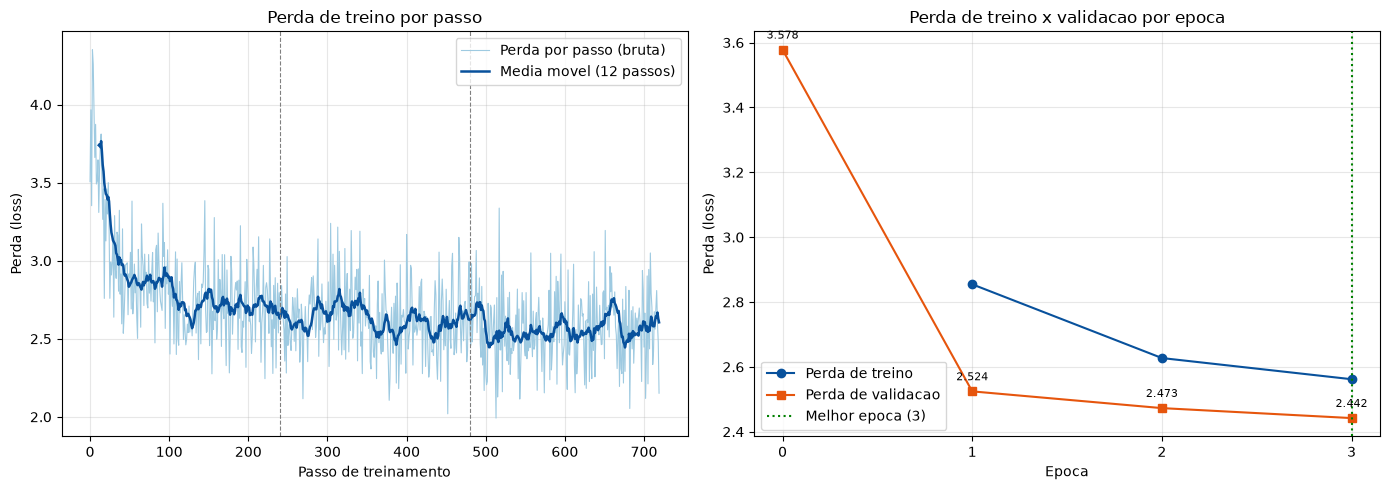

Grafico salvo em: D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\modelos_v2\grafico_perda.png


In [23]:
passos_por_epoca = len(carregador_treino)
figura, (eixo_a, eixo_b) = plt.subplots(1, 2, figsize=(14, 5))

# ---- painel esquerdo: perda por passo ----
eixo_a.plot(historico_passos, color="#9ecae1", linewidth=0.8, label="Perda por passo (bruta)")

janela = max(5, passos_por_epoca // 20)
if len(historico_passos) >= janela:
    serie = pd.Series(historico_passos).rolling(janela).mean()
    eixo_a.plot(serie, color="#08519c", linewidth=1.8, label=f"Media movel ({janela} passos)")

for numero in range(1, len(historico_epocas)):
    eixo_a.axvline(numero * passos_por_epoca, color="gray", linestyle="--", linewidth=0.8)

eixo_a.set_title("Perda de treino por passo")
eixo_a.set_xlabel("Passo de treinamento")
eixo_a.set_ylabel("Perda (loss)")
eixo_a.legend()
eixo_a.grid(True, alpha=0.3)

# ---- painel direito: perda por epoca ----
epocas = [h["epoca"] for h in historico_epocas]
perdas_tr = [h["perda_treino"] for h in historico_epocas]
perdas_va = [h["perda_validacao"] for h in historico_epocas]

eixo_b.plot(epocas, perdas_tr, marker="o", color="#08519c", label="Perda de treino")
eixo_b.plot([0] + epocas, [perda_validacao_inicial] + perdas_va, marker="s",
            color="#e6550d", label="Perda de validacao")

for x, y in zip([0] + epocas, [perda_validacao_inicial] + perdas_va):
    eixo_b.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8)

if melhor_epoca is not None:
    eixo_b.axvline(melhor_epoca, color="green", linestyle=":", linewidth=1.5,
                   label=f"Melhor epoca ({melhor_epoca})")

eixo_b.set_title("Perda de treino x validacao por epoca")
eixo_b.set_xlabel("Epoca")
eixo_b.set_ylabel("Perda (loss)")
eixo_b.set_xticks([0] + epocas)
eixo_b.legend()
eixo_b.grid(True, alpha=0.3)

plt.tight_layout()
figura.savefig(PASTA_MODELOS / "grafico_perda.png", dpi=150, bbox_inches="tight")
plt.show()

print("Grafico salvo em:", (PASTA_MODELOS / "grafico_perda.png").resolve())

## 8. Salvando o modelo treinado

**O que faz:** grava o adaptador da **melhor epoca** em `modelos_v2/lora_final`, junto com o tokenizador e um
`metricas.json` contendo todos os hiperparametros e o historico das perdas.

**Por que:** `save_pretrained` salva **apenas o adaptador LoRA**, nao o GPT-2 inteiro - por isso o arquivo tem
poucos megabytes em vez de centenas. Guardar os hiperparametros junto e o que permite reproduzir e explicar o
resultado depois; sem eles, o adaptador e um arquivo sem historia.

**O que observar:** o `adapter_model.safetensors` deve ter cerca de 1,2 MB. O tokenizador e salvo junto para
que a aplicacao carregue tudo de uma pasta so.

In [24]:
PASTA_FINAL = PASTA_MODELOS / "lora_final"
origem = PASTA_MODELOS / f"lora_epoca_{melhor_epoca}"

import shutil
if PASTA_FINAL.exists():
    shutil.rmtree(PASTA_FINAL)
shutil.copytree(origem, PASTA_FINAL)

metricas = {
    "modelo_base": MODELO_BASE,
    "epocas": EPOCAS,
    "taxa_aprendizado": TAXA_APRENDIZADO,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH,
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "target_modules": ["c_attn"],
    "semente": SEMENTE,
    "perda_validacao_inicial": perda_validacao_inicial,
    "melhor_epoca": melhor_epoca,
    "melhor_perda_validacao": melhor_perda,
    "historico_epocas": historico_epocas,
    "temperatura_padrao": TEMPERATURA,
    "penalidade_padrao": PENALIDADE_REPETICAO,
}

with open(PASTA_FINAL / "metricas.json", "w", encoding="utf-8") as arquivo:
    json.dump(metricas, arquivo, ensure_ascii=False, indent=4)

print("Adaptador final (epoca", melhor_epoca, ") salvo em:", PASTA_FINAL.resolve())
for item in sorted(PASTA_FINAL.iterdir()):
    print(f"  - {item.name}: {item.stat().st_size/1024:.1f} KB")

Adaptador final (epoca 3 ) salvo em: D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\modelos_v2\lora_final
  - adapter_config.json: 1.1 KB
  - adapter_model.safetensors: 1155.0 KB
  - metricas.json: 1.1 KB
  - README.md: 5.1 KB
  - tokenizer.json: 3575.7 KB
  - tokenizer_config.json: 0.4 KB


## 9. Recarregando o adaptador salvo

**O que faz:** apaga o modelo da memoria, recarrega o GPT-2 base do zero, aplica o adaptador salvo com
`PeftModel.from_pretrained` e confirma que o resultado funciona.

**Por que:** este e o **passo 8 do enunciado** e estava ausente na versao anterior do projeto. Ele importa
por um motivo pratico: e exatamente assim que a **aplicacao do grupo** vai carregar o modelo. Se este teste
nao passar, o adaptador entregue no zip nao funciona na mao do avaliador, por melhor que tenha sido o treino.

**A verificacao:** a perda de validacao do modelo recarregado e comparada com a da melhor epoca. Elas devem
ser praticamente identicas (diferenca menor que 0,01). Se divergirem, algo se perdeu no salvamento.

**Observacao:** `PeftModel.from_pretrained` carrega o adaptador em modo de inferencia. Para continuar
treinando seria preciso `is_trainable=True`, o que nao e o caso aqui.

In [25]:
from peft import PeftModel

# Descarrega tudo para provar que o carregamento nao depende do estado anterior.
del modelo, modelo_base, otimizador
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_recarregada = AutoModelForCausalLM.from_pretrained(MODELO_BASE)
base_recarregada.config.pad_token_id = tokenizador.pad_token_id

modelo_final = PeftModel.from_pretrained(base_recarregada, str(PASTA_FINAL))
modelo_final.to(dispositivo)
modelo_final.eval()

print("Adaptador recarregado de:", PASTA_FINAL)
print("Tipo:", type(modelo_final).__name__)

perda_recarregada = avaliar_perda(modelo_final, carregador_validacao)
print(f"\nPerda de validacao da melhor epoca : {melhor_perda:.4f}")
print(f"Perda de validacao apos recarregar  : {perda_recarregada:.4f}")
print(f"Diferenca: {abs(perda_recarregada - melhor_perda):.6f}")

assert abs(perda_recarregada - melhor_perda) < 0.01, "O modelo recarregado nao reproduz o treinado!"
print("\nOK: o adaptador salvo reproduz o modelo treinado.")

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 17466.50it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Adaptador recarregado de: modelos_v2\lora_final
Tipo: PeftModelForCausalLM

Perda de validacao da melhor epoca : 2.4421
Perda de validacao apos recarregar  : 2.4421
Diferenca: 0.000000

OK: o adaptador salvo reproduz o modelo treinado.


## 10. Conversando com o modelo ajustado

### 10.1 Antes e depois, lado a lado

**O que faz:** refaz as tres perguntas fixas da Secao 7.4, agora com o modelo recarregado, e monta uma tabela
comparativa.

**Por que:** e a evidencia qualitativa do efeito do treino. A comparacao e justa porque usa as mesmas perguntas,
a mesma funcao e `amostragem=False` nos dois momentos - a unica variavel que mudou e o adaptador LoRA.

**O que analisar honestamente:**

- o modelo passou a **reconhecer o formato** de pergunta e resposta?
- as respostas ficaram **dentro do tema de negocios**?
- o modelo **para sozinho** (coluna `parou`) ou vai ate o limite de tokens?

**Aviso do professor, que vale repetir:** melhora na perda **nao garante** resposta boa. Um modelo de 124M
parametros treinado com 960 exemplos ainda erra concordancia, repete e afirma coisas erradas com confianca.
Isso deve aparecer na apresentacao, nao ser escondido.

In [26]:
comparacao = []
for pergunta in PERGUNTAS_FIXAS:
    depois, parou = responder(pergunta, modelo_geracao=modelo_final, amostragem=False)
    comparacao.append({
        "pergunta": pergunta,
        "antes (GPT-2 original)": respostas_antes[pergunta] or "(vazia)",
        "depois (com LoRA)": depois or "(vazia)",
        "parou": "sim" if parou else "nao",
    })

    print("PERGUNTA:", pergunta)
    print("  ANTES :", (respostas_antes[pergunta] or "(vazia)")[:200])
    print("  DEPOIS:", (depois or "(vazia)")[:200])
    print("-" * 95)

df_comparacao = pd.DataFrame(comparacao)
display(df_comparacao)

PERGUNTA: Como uma pequena empresa pode fidelizar seus clientes?
  ANTES : A resposta é que a empresa não tem nenhuma razão para fazer isso.

O que se sabe sobre o assunto, é que os consumidores são muito mais numerosos do que as empresas de tecnologia e podem ser facilmente
  DEPOIS: A pequena empresa deve ser capaz de oferecer serviços que atendam às necessidades dos clientes. A equipe da empresa precisa ter um foco em atender aos clientes e fornecer soluções para satisfazer os d
-----------------------------------------------------------------------------------------------
PERGUNTA: Quais sao os principais indicadores financeiros de um negocio?
  ANTES : A resposta é que o preço do mercado financeiro não depende da quantidade de dinheiro investido. A quantidade total de dinheiro investidos no mercado financeiro pode ser muito maior, mas a quantidade d
  DEPOIS: Os principais indicadores econômicos são o índice de crescimento econômico, a taxa de desemprego e as taxas de juros.
-----

,pergunta,antes (GPT-2 original),depois (com LoRA),parou
0,Como uma pequena empresa pode fidelizar seus clientes?,"A resposta é que a empresa não tem nenhuma razão para fazer isso.\n\nO que se sabe sobre o assunto, é que os consumidores são muito mais numerosos do que as empresas de tecnologia e podem ser facilmente confundidos com outras pessoas ou mesmo até mesmo um grupo de pessoas diferentes.\nA empresa também possui vantagens em relação ao cliente, pois eles têm acesso aos serviços oferecidos por outros fornecedores (","A pequena empresa deve ser capaz de oferecer serviços que atendam às necessidades dos clientes. A equipe da empresa precisa ter um foco em atender aos clientes e fornecer soluções para satisfazer os desejos do cliente. A organização também tem a capacidade de criar conteúdo, desenvolver produtos e promover eventos relacionados à empresa.",sim
1,Quais sao os principais indicadores financeiros de um negocio?,"A resposta é que o preço do mercado financeiro não depende da quantidade de dinheiro investido. A quantidade total de dinheiro investidos no mercado financeiro pode ser muito maior, mas a quantidade de capital investido deve estar em conta própria.\n\nO mercado financeiro tem uma relação inversa com as ações dos investidores e seus corretores (ou seja, como se diz o economista americano Milton Friedman, ""a moeda corrente está","Os principais indicadores econômicos são o índice de crescimento econômico, a taxa de desemprego e as taxas de juros.",sim
2,Como definir o preco de um produto novo?,"O produto novo é uma função que retorna a partir do modelo de entrada.\n\nA função ""f"" é uma variável aleatória, e pode ser escrita como\n\nformula_1\n\nonde formula_2 denota a probabilidade da variável aleatória ter sido gerada.\nA variável aleatória ""x"", por sua vez, tem a propriedade de não se transformar em uma variável contínua.\nO modelo","O primeiro produto novo é uma máquina de escrever. O produto pode ser qualquer dispositivo, incluindo computadores pessoais e dispositivos móveis. O dispositivo pode ter um teclado ou mouse para controlar a programação do produto. O software também pode ser usado para criar aplicativos personalizados que podem ser usados em outros produtos. O aplicativo pode fornecer recursos adicionais como gráficos vetoriais, animações e efeitos visuais.",sim


### 10.2 O efeito da TEMPERATURA

**O que faz:** repete a mesma pergunta com temperaturas crescentes, mantendo tudo o mais igual.

**Por que:** a temperatura e um dos cinco parametros que a aplicacao deve expor, e o professor pede que o
usuario "veja o efeito". Esta celula produz exatamente essa demonstracao.

**Como a temperatura funciona:** ela achata ou aguca a distribuicao de probabilidade do proximo token.

| Temperatura | Comportamento esperado |
|---|---|
| 0,2 | Conservadora: escolhe quase sempre o token mais provavel. Previsivel e repetitiva. |
| 0,8 | Equilibrio - e o valor padrao sugerido pelo professor. |
| 1,5 | Criativa: aumenta a chance de tokens improvaveis. Tende a perder coerencia e fugir do tema. |

**O que observar:** a mesma pergunta deve produzir respostas visivelmente mais soltas conforme o valor sobe.
Em 1,5, e comum aparecerem frases sem sentido - isso nao e defeito do treino, e o efeito do parametro.

In [27]:
pergunta_demo = PERGUNTAS_FIXAS[0]
print("PERGUNTA:", pergunta_demo)
print("=" * 95)

linhas_temp = []
for temp in [0.2, 0.8, 1.5]:
    torch.manual_seed(SEMENTE)   # mesma semente: isola o efeito da temperatura
    texto, parou = responder(pergunta_demo, modelo_geracao=modelo_final,
                             temperatura=temp, amostragem=True)
    linhas_temp.append({"temperatura": temp, "resposta": texto or "(vazia)",
                        "parou": "sim" if parou else "nao"})
    print(f"\n--- temperatura = {temp} ---")
    print(texto or "(vazia)")

display(pd.DataFrame(linhas_temp))

PERGUNTA: Como uma pequena empresa pode fidelizar seus clientes?

--- temperatura = 0.2 ---
Uma pequena empresa poderia fazer um negócio de marketing com o objetivo de atrair e vender produtos. Eles poderiam oferecer serviços, anúncios para sites específicos ou criar conteúdo próprio. Eles também podem fornecer suporte ao cliente através do envio de mensagens via web, como SMSs, SMS-SMS, etc. Eles teriam acesso a recursos financeiros disponíveis para ajudar os funcionários da empresa em suas tarefas diárias. Eles provavelmente iriam se

--- temperatura = 0.8 ---
Uma pequena empresa poderia, se possível, prestar serviços de atendimento a pessoas que vivem em cidades maiores e mais populosas. Isso incluiria serviços médicos (como o Hospital St. Mary's), clínicas médicas (como a Clínica de Neurocirurgia do Hospital St Vincent) entre outras atividades físicas como assistência médica privada e consultoria. Além disso, as empresas poderiam oferecer serviços educacionais gratuitamente para os

,temperatura,resposta,parou
0,0.2,"Uma pequena empresa poderia fazer um negócio de marketing com o objetivo de atrair e vender produtos. Eles poderiam oferecer serviços, anúncios para sites específicos ou criar conteúdo próprio. Eles também podem fornecer suporte ao cliente através do envio de mensagens via web, como SMSs, SMS-SMS, etc. Eles teriam acesso a recursos financeiros disponíveis para ajudar os funcionários da empresa em suas tarefas diárias. Eles provavelmente iriam se",nao
1,0.8,"Uma pequena empresa poderia, se possível, prestar serviços de atendimento a pessoas que vivem em cidades maiores e mais populosas. Isso incluiria serviços médicos (como o Hospital St. Mary's), clínicas médicas (como a Clínica de Neurocirurgia do Hospital St Vincent) entre outras atividades físicas como assistência médica privada e consultoria. Além disso, as empresas poderiam oferecer serviços educacionais gratuitamente para os estudantes que desejam entrar",nao
2,1.5,"Definamos os anúncios com imagens, anúncios personalizados e fotos de vários membros. Nósos também são mais capacitadores que a maioria dos seus compradores ou mentores na indústria da televisão para fazer bons filmes fotográficos corretamente e obter lucro financeiro quando estamos jogando. Os principais desafios do departamento foram ajudar nossa equipe manter-nos estáveis após as nossas mudanças em dezembro de 2016, e nossos esforços atuais incluíram o estabelecimento",nao


### 10.3 O efeito da PENALIDADE DE REPETICAO

**O que faz:** repete a mesma pergunta variando apenas `repetition_penalty`.

**Por que:** e o quinto parametro exposto, e o professor o chama de "antidoto do loop". Modelos pequenos
treinados com pouco dado tendem a repetir a mesma frase indefinidamente; este controle segura isso.

| Penalidade | Comportamento esperado |
|---|---|
| 1,0 | Desligada. E aqui que o loop costuma aparecer. |
| 1,2 | Valor sugerido pelo professor. Equilibra fluidez e variedade. |
| 1,5 | Agressiva. Evita repeticao, mas pode forcar palavras estranhas e quebrar a coerencia. |

**Medida objetiva:** a coluna `palavras_unicas` mostra a fracao de palavras distintas na resposta. Quanto mais
proximo de 1, menos repeticao. E uma forma de sustentar a analise com numero, e nao so com impressao.

> Note que `no_repeat_ngram_size=3` continua ativo em todos os casos, entao mesmo com penalidade 1,0 a
> repeticao literal de trechos de 3 tokens ja esta bloqueada. O efeito visivel e, portanto, conservador.

In [28]:
def fracao_palavras_unicas(texto):
    palavras = re.findall(r"\w+", (texto or "").lower())
    if not palavras:
        return 0.0
    return len(set(palavras)) / len(palavras)


print("PERGUNTA:", pergunta_demo)
print("=" * 95)

linhas_pen = []
for pen in [1.0, 1.2, 1.5]:
    torch.manual_seed(SEMENTE)
    texto, parou = responder(pergunta_demo, modelo_geracao=modelo_final,
                             penalidade=pen, amostragem=True)
    linhas_pen.append({
        "penalidade": pen,
        "resposta": texto or "(vazia)",
        "palavras_unicas": round(fracao_palavras_unicas(texto), 3),
        "parou": "sim" if parou else "nao",
    })
    print(f"\n--- penalidade = {pen} ---")
    print(texto or "(vazia)")

display(pd.DataFrame(linhas_pen))

PERGUNTA: Como uma pequena empresa pode fidelizar seus clientes?

--- penalidade = 1.0 ---
Uma pequena empresa poderia fidelizá-los com marketing, marketing de sucesso e marketing de apoio. O marketing de venda pode ser realizado em áreas como publicidade, educação e marketing. As campanhas de marketing de marketing podem incluir anúncios de produtos e serviços, anúncios de "marketing" e campanhas de produtos. A comunicação pode ser utilizada para promover as empresas para ganhar clientes. O apoio pode ser fornecido de forma

--- penalidade = 1.2 ---
Uma pequena empresa poderia, se possível, prestar serviços de atendimento a pessoas que vivem em cidades maiores e mais populosas. Isso incluiria serviços médicos (como o Hospital St. Mary's), clínicas médicas (como a Clínica de Neurocirurgia do Hospital St Vincent) entre outras atividades físicas como assistência médica privada e consultoria. Além disso, as empresas poderiam oferecer serviços educacionais gratuitamente para os estudantes 

,penalidade,resposta,palavras_unicas,parou
0,1.0,"Uma pequena empresa poderia fidelizá-los com marketing, marketing de sucesso e marketing de apoio. O marketing de venda pode ser realizado em áreas como publicidade, educação e marketing. As campanhas de marketing de marketing podem incluir anúncios de produtos e serviços, anúncios de ""marketing"" e campanhas de produtos. A comunicação pode ser utilizada para promover as empresas para ganhar clientes. O apoio pode ser fornecido de forma",0.574,nao
1,1.2,"Uma pequena empresa poderia, se possível, prestar serviços de atendimento a pessoas que vivem em cidades maiores e mais populosas. Isso incluiria serviços médicos (como o Hospital St. Mary's), clínicas médicas (como a Clínica de Neurocirurgia do Hospital St Vincent) entre outras atividades físicas como assistência médica privada e consultoria. Além disso, as empresas poderiam oferecer serviços educacionais gratuitamente para os estudantes que desejam entrar",0.848,nao
2,1.5,"Uma pequena empresa poderia, se possível, prestar serviços de atendimento a pessoas que vivem em cidades maiores e mais populosas. Isso incluiria assistência médica (conveniência), treinamento empresarial para funcionários da área do trabalho ou empresas voltadas à pesquisa social especializada; consultoria estratégica para profissionais liberais como advogados clínicos gerais especializados com especialização no mercado financeiro ; tecnologia educacional especializado para professores universitários na Faculdade de Direito de Boston; técnicas",0.941,nao


## 11. Avaliacao no conjunto de teste

**O que faz:** mede a perda nos 120 exemplos **nunca vistos** e converte o resultado em perplexidade.

**Por que:** ate aqui a validacao foi usada para escolher a melhor epoca - portanto ela influenciou decisoes e
ja nao e totalmente imparcial. O teste foi separado na Secao 2.5 e guardado justamente para este momento. E a
prova final, usada **uma unica vez**.

**Perplexidade** e a perda transformada em algo mais intuitivo: `exp(perda)`. Ela indica, grosso modo, entre
quantas opcoes o modelo hesita a cada token. Menor e melhor.

**Como interpretar:** se a perda de teste ficar proxima da de validacao, o resultado **generaliza** - o modelo
nao decorou o conjunto usado para escolher a epoca. Uma perda de teste bem maior indicaria que as decisoes
foram ajustadas demais a validacao.

In [29]:
import math

perda_teste = avaliar_perda(modelo_final, carregador_teste)
perda_validacao_final = perda_recarregada

print(f"Perda de validacao : {perda_validacao_final:.4f}  | perplexidade {math.exp(perda_validacao_final):.1f}")
print(f"Perda de TESTE     : {perda_teste:.4f}  | perplexidade {math.exp(perda_teste):.1f}")
print(f"\nPonto de partida (antes do treino): {perda_validacao_inicial:.4f}")
print(f"Reducao total na validacao: {perda_validacao_inicial - perda_validacao_final:.4f}")

diferenca = abs(perda_teste - perda_validacao_final)
print(f"\nDiferenca teste x validacao: {diferenca:.4f}")
if diferenca < 0.15:
    print("Interpretacao: valores proximos - o resultado generaliza para dados novos.")
else:
    print("Interpretacao: diferenca relevante - as escolhas podem ter se ajustado demais a validacao.")

Perda de validacao : 2.4421  | perplexidade 11.5
Perda de TESTE     : 2.4051  | perplexidade 11.1

Ponto de partida (antes do treino): 3.5779
Reducao total na validacao: 1.1358

Diferenca teste x validacao: 0.0371
Interpretacao: valores proximos - o resultado generaliza para dados novos.


## 12. Analise estruturada de erros

### 12.1 Geracao das respostas de teste

**O que faz:** gera respostas para 30 exemplos do conjunto de teste e calcula, para cada uma, sinais
automaticos de qualidade.

**Por que:** o professor exige mais do que cinco exemplos escolhidos a dedo. Ele diz que o modelo vai "falar
coisa errada com confianca" e que o grupo deve **mostrar isso**. Uma amostra maior, com criterios explicitos,
sustenta essa analise melhor do que impressoes soltas.

**Os cinco sinais medidos** (todos calculados localmente, sem nenhuma API externa):

| Sinal | Como e medido | Problema que revela |
|---|---|---|
| `vazia` | resposta sem nenhum caractere | O modelo nao produziu nada |
| `nao_parou` | nao gerou `eos` dentro do limite | "Nao para de escrever" |
| `repetitiva` | menos de 60% de palavras distintas | "Repete a mesma frase sem parar" |
| `copiou_pergunta` | 70%+ das palavras vem da pergunta | "Copia a pergunta na resposta" |
| `aderencia` | sobreposicao de palavras com a resposta esperada | Fuga do tema |

**Limite honesto:** `aderencia` compara vocabulario, nao significado. Uma resposta correta escrita com outras
palavras recebe nota baixa, e uma resposta errada com as palavras certas recebe nota alta. Serve para
**ordenar candidatos a inspecao manual**, nao como nota de qualidade.

In [30]:
STOPWORDS = {
    "a", "o", "as", "os", "de", "da", "do", "das", "dos", "e", "em", "no", "na",
    "nos", "nas", "um", "uma", "uns", "umas", "para", "por", "com", "que", "se",
    "ao", "aos", "as", "sua", "seu", "suas", "seus", "mais", "como", "ou", "ser",
}


def palavras_conteudo(texto):
    return {p for p in re.findall(r"\w+", (texto or "").lower())
            if p not in STOPWORDS and len(p) > 2}


def aderencia(gerada, esperada):
    a, b = palavras_conteudo(gerada), palavras_conteudo(esperada)
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


N_AMOSTRA = 30
amostra_teste = df_teste.sample(N_AMOSTRA, random_state=SEMENTE)

registros = []
for _, linha in tqdm(list(amostra_teste.iterrows()), desc="Avaliando teste"):
    gerada, parou = responder(linha["instruction"], linha["input"],
                              modelo_geracao=modelo_final, amostragem=False)
    registros.append({
        "pergunta": linha["instruction"],
        "contexto": linha["input"],
        "esperada": linha["output"],
        "gerada": gerada,
        "vazia": len(gerada.strip()) == 0,
        "nao_parou": not parou,
        "repetitiva": fracao_palavras_unicas(gerada) < 0.6,
        "copiou_pergunta": aderencia(gerada, linha["instruction"]) > 0.7,
        "aderencia": round(aderencia(gerada, linha["output"]), 3),
    })

df_erros = pd.DataFrame(registros)
print("Respostas geradas:", len(df_erros))

Avaliando teste: 100%|██████████| 30/30 [00:26<00:00,  1.12it/s]

Respostas geradas: 30


### 12.2 Panorama dos problemas encontrados

**O que faz:** resume quantas respostas apresentaram cada problema e mostra a distribuicao da aderencia.

**Por que:** transforma a analise qualitativa em numeros que cabem em um slide. Cada linha da tabela se liga
diretamente a um sintoma da tabela de problemas do professor, junto com a acao recomendada por ele.

**Como usar o resultado na apresentacao:**

- muitos casos de `nao_parou` -> conferir o `eos_token` no final de cada exemplo (feito na Secao 3.3);
- muitos casos de `repetitiva` -> subir a penalidade de repeticao, depois treinar mais epocas;
- `aderencia` mediana baixa -> treinou pouco; aumentar `EPOCAS` antes de mexer em qualquer outra coisa.

In [31]:
problemas = ["vazia", "nao_parou", "repetitiva", "copiou_pergunta"]

resumo_erros = pd.DataFrame({
    "casos": [int(df_erros[c].sum()) for c in problemas],
    "percentual": [round(df_erros[c].mean() * 100, 1) for c in problemas],
}, index=problemas)
display(resumo_erros)

print("Aderencia ao texto esperado (0 a 1):")
print(df_erros["aderencia"].describe().round(3).to_string())

sem_problema = (~df_erros[problemas].any(axis=1)).sum()
print(f"\nRespostas sem nenhum dos problemas listados: {sem_problema} de {len(df_erros)}")

,casos,percentual
vazia,0,0.0
nao_parou,9,30.0
repetitiva,0,0.0
copiou_pergunta,0,0.0


Aderencia ao texto esperado (0 a 1):
count    30.000
mean      0.101
std       0.091
min       0.000
25%       0.038
50%       0.073
75%       0.138
max       0.400

Respostas sem nenhum dos problemas listados: 21 de 30


### 12.3 Os piores e os melhores casos

**O que faz:** mostra as tres respostas de menor aderencia e as tres de maior aderencia.

**Por que:** os extremos sao o material mais util para a apresentacao. Os piores casos revelam **como** o
modelo falha - e o professor deixa claro que responder mal nao derruba a nota, mas nao saber explicar o porque
derruba. Os melhores casos mostram que o formato foi aprendido.

**O que procurar nos piores casos:**

- **invencao com confianca** - o modelo afirma dados que nao existem na base;
- **erro herdado do dado** - a base tem defeitos de proposito e o modelo aprende o erro;
- **incoerencia gramatical** - esperado num modelo de 124M parametros;
- **resposta generica** - o modelo aprendeu o formato, mas nao o conteudo.

Vale conferir se algum caso ruim corresponde a um `output` defeituoso da propria base (Secao 2.4). Quando isso
acontece, a culpa e do dado, nao do treino - e essa distincao rende uma boa analise.

In [32]:
colunas = ["pergunta", "esperada", "gerada", "aderencia"]

print("=" * 95)
print("PIORES CASOS (menor aderencia)")
print("=" * 95)
for _, r in df_erros.nsmallest(3, "aderencia").iterrows():
    print("PERGUNTA :", r["pergunta"][:110])
    if str(r["contexto"]).strip():
        print("CONTEXTO :", str(r["contexto"])[:110])
    print("ESPERADA :", str(r["esperada"])[:180])
    print("GERADA   :", (r["gerada"] or "(vazia)")[:180])
    print("aderencia:", r["aderencia"])
    print("-" * 95)

print("\n" + "=" * 95)
print("MELHORES CASOS (maior aderencia)")
print("=" * 95)
for _, r in df_erros.nlargest(3, "aderencia").iterrows():
    print("PERGUNTA :", r["pergunta"][:110])
    print("ESPERADA :", str(r["esperada"])[:180])
    print("GERADA   :", (r["gerada"] or "(vazia)")[:180])
    print("aderencia:", r["aderencia"])
    print("-" * 95)

PIORES CASOS (menor aderencia)
PERGUNTA : Escreva um diálogo simples entre o cliente e o lojista
ESPERADA : Cliente: Oi, estou procurando alguns móveis novos para a minha sala de estar. Shopkeeper: Claro, que tipo de mobiliário você está procurando? Cliente: Estou pensando em um sofá e u
GERADA   : O lojistas são os clientes mais importantes do mundo. Eles podem ser pessoas que gostam de negócios, mas não querem gastar dinheiro ou se preocupar com a aparência física dos produ
aderencia: 0.0
-----------------------------------------------------------------------------------------------
PERGUNTA : Descreva o que é uma “Bubble de Mercado”.
ESPERADA : Uma bolha de mercado é um fenômeno econômico em que o preço de um ativo ou grupo de ativos aumenta significativamente além de seu valor real, alimentado pela especulação e, eventua
GERADA   : A bubble é um mercado onde os compradores podem comprar produtos e serviços. Os vendedores escolhem quais itens eles querem adquirir, como roupas, acess

### 12.4 Exportacao dos resultados

**O que faz:** salva a tabela completa da analise em CSV, junto do adaptador final.

**Por que:** cria um registro permanente e independente do notebook. `utf-8-sig` faz o Excel no Windows abrir
os acentos corretamente. Manter o CSV ao lado do modelo mantem resultado e artefato associados.

In [33]:
caminho_csv = PASTA_FINAL / "analise_erros_teste.csv"
df_erros.to_csv(caminho_csv, index=False, encoding="utf-8-sig")

df_comparacao.to_csv(PASTA_FINAL / "antes_depois.csv", index=False, encoding="utf-8-sig")

print("Salvos:")
print(" -", caminho_csv.resolve())
print(" -", (PASTA_FINAL / "antes_depois.csv").resolve())

Salvos:
 - D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\modelos_v2\lora_final\analise_erros_teste.csv
 - D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\modelos_v2\lora_final\antes_depois.csv


## 13. Conclusoes, limitacoes e diagnostico

### 13.1 Resumo do experimento

**O que faz:** consolida os numeros principais numa tabela unica.

**Por que:** e o slide de fechamento. Reune o que foi decidido, o que foi medido e onde estao os artefatos.

In [34]:
print("=" * 60)
print("RESUMO DO EXPERIMENTO")
print("=" * 60)
print(f"Modelo base          : {MODELO_BASE}")
print(f"Base de dados        : {CAMINHO_DADOS} ({len(df)} pares)")
print(f"Divisao              : {len(df_treino)} treino / {len(df_validacao)} validacao / {len(df_teste)} teste")
print(f"Parametros treinados : {treinaveis:,} ({percentual:.4f}% do modelo)")
print(f"Epocas               : {EPOCAS}")
print(f"Taxa de aprendizado  : {TAXA_APRENDIZADO}")
print(f"Tamanho do lote      : {BATCH_SIZE}")
print(f"MAX_LENGTH           : {MAX_LENGTH}")
print("-" * 60)
print(f"Perda validacao inicial : {perda_validacao_inicial:.4f}")
print(f"Perda validacao final   : {perda_validacao_final:.4f}  (melhor epoca: {melhor_epoca})")
print(f"Perda de TESTE          : {perda_teste:.4f}")
print("-" * 60)
print(f"Adaptador final : {PASTA_FINAL.resolve()}")
print(f"Grafico da perda: {(PASTA_MODELOS / 'grafico_perda.png').resolve()}")
print("=" * 60)

RESUMO DO EXPERIMENTO
Modelo base          : pierreguillou/gpt2-small-portuguese
Base de dados        : data\negocios.jsonl (1200 pares)
Divisao              : 960 treino / 120 validacao / 120 teste
Parametros treinados : 294,912 (0.2364% do modelo)
Epocas               : 3
Taxa de aprendizado  : 0.0005
Tamanho do lote      : 4
MAX_LENGTH           : 256
------------------------------------------------------------
Perda validacao inicial : 3.5779
Perda validacao final   : 2.4421  (melhor epoca: 3)
Perda de TESTE          : 2.4051
------------------------------------------------------------
Adaptador final : D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\modelos_v2\lora_final
Grafico da perda: D:\ESTUDOS\UNIFOR\int-aprendizado-maquina\modelos_v2\grafico_perda.png


### 13.2 O que foi cumprido do enunciado

| Requisito do professor | Situacao | Onde |
|---|---|---|
| Modelo `pierreguillou/gpt2-small-portuguese` | Cumprido | Secao 5 |
| Instalar `transformers peft accelerate` | Cumprido (era o que faltava) | Secao 1.2 |
| `pad_token = eos_token` | Cumprido | Secao 3.1 |
| LoRA `r=8`, `alpha=16`, `c_attn`, `dropout=0.05` | Cumprido | Secao 6 |
| Menos de 1% dos parametros treinaveis | Cumprido - 0,24% | Secao 6 |
| Formato fixo, igual no treino e na conversa | Cumprido e **provado com `assert`** | Secao 3.3 |
| `eos_token` no fim de cada exemplo | Cumprido e verificado nos 960 exemplos | Secao 3.3 |
| Padding ignorado na perda (`-100`) | Cumprido | Secao 4.2 |
| Acompanhar a perda | Cumprido - por passo e por epoca | Secao 7.7 |
| **Plotar o grafico da perda** | Cumprido | Secao 7.8 |
| Salvar o adaptador LoRA | Cumprido | Secao 8 |
| **Recarregar com `PeftModel.from_pretrained`** | Cumprido e **verificado numericamente** | Secao 9 |
| Conversar com `temperatura`, `penalidade`, `top_p` | Cumprido | Secao 7.3 |
| Expor epocas, taxa, lote, temperatura, penalidade | Cumprido - centralizados | Secao 7.1 |
| Nao usar API de LLM comercial | Cumprido - nenhuma chamada externa | todo o notebook |
| Nao incluir a base no zip | A base fica em `data/`, fora da entrega | - |

**Alem do pedido:** divisao com checagem de vazamento (2.5), avaliacao no conjunto de teste (11) e analise
estruturada de erros em 30 exemplos (12).

### 13.3 Limitacoes conhecidas

Estas sao as fraquezas reais do trabalho. O professor e explicito: responder mal nao derruba a nota; nao saber
explicar por que, sim.

1. **O modelo e pequeno.** 124M parametros e pouco. Erros de concordancia e frases mal construidas sao
   esperados e nao indicam falha do treino.
2. **A base e pequena e tem defeitos de proposito.** 960 exemplos de treino nao cobrem o dominio de negocios.
   Alguns `output` da base sao ruins (ha ate um com 1 caractere, Secao 2.4) e **o modelo aprende o erro do
   dado** - por isso alguns erros da Secao 12.3 tem origem na base, nao no ajuste.
3. **A perda mede previsao de tokens, nao verdade.** Perda menor significa prever melhor as palavras do texto
   esperado. Nao mede correcao factual. Por isso o notebook combina numero (11) e inspecao (12).
4. **A metrica de aderencia compara vocabulario, nao significado.** Serve para ordenar casos para inspecao
   manual, nao como nota de qualidade.
5. **O modelo inventa com confianca.** E o comportamento mais perigoso para uma aplicacao real e a razao pela
   qual um sistema como este nao deve ser usado para orientar decisoes de negocio de verdade.
6. **A amostra da analise de erros e de 30 exemplos.** Suficiente para indicar tendencias, insuficiente para
   conclusoes estatisticas.

### 13.4 Guia de diagnostico

Tabela de problemas do enunciado, com o que este notebook ja faz a respeito de cada um.

| Sintoma | Por onde comecar | Onde tratamos |
|---|---|---|
| Repete a mesma frase sem parar | Subir a penalidade de repeticao; depois treinar mais epocas | Secao 10.3 mede o efeito |
| Nao para de escrever | Confirmar o `eos_token` no fim de cada exemplo de treino | Secao 3.3 verifica nos 960 |
| Responde fora do tema | Treinou pouco - aumentar as epocas antes de mexer em outra coisa | `EPOCAS` na Secao 7.1 |
| Copia a pergunta na resposta | Formato de treino e de conversa diferentes - comparar os dois | Secao 3.3 prova que sao iguais |
| Fala coisa errada com confianca | Esperado: a base tem erros e o modelo aprende o erro do dado | Secoes 12.3 e 13.3 |
| Demora demais | Ativar a GPU ou reduzir `max_length` | Secoes 1.1 e 4.1 |
| `CUDA out of memory` | Reduzir `BATCH_SIZE` para 2 | Secao 7.1 |

### 13.5 Proximos passos

- Treinar mais epocas monitorando a validacao: parar quando ela subir (overfitting).
- Testar `r=16` no LoRA, ou incluir `c_proj` alem de `c_attn`, para dar mais capacidade de ajuste.
- Limpar os `output` defeituosos da base e comparar o efeito - separando erro do dado de erro do modelo.
- Aumentar a amostra da analise de erros e revisar manualmente, classificando os tipos de invencao.